# Modelo Variacão 3: Ensemble (DenseNet169 + InceptionV3 + EfficientNetV2)

Este notebook implementa um Ensemble ponderado utilizando três arquiteturas distintas:
- **DenseNet-169:** Focada em conectividade densa e reaproveitamento de features.
- **InceptionV3:** Utiliza convoluções fatoradas e módulos Inception para capturar features em múltiplas escalas.
- **EfficientNetV2-S:** Otimizada para velocidade de treinamento e eficiência de parâmetros.

**Técnicas inclusas:**
- **Fine-Tuning Parcial:** Ajuste fino nas camadas superiores de cada modelo.
- **Data Augmentation Robusto:** Resize(330), RandomResizedCrop(299), Flips, Rotation, ColorJitter e RandomErasing.
- **Test Time Augmentation (TTA):** Inferência baseada na média de múltiplas versões aumentadas da mesma imagem.
- **Weighted Ensemble:** Combinação das predições ponderada pelo F1-Score obtido na validação.

In [1]:
# =========================================================
# Setup: Bibliotecas e Reprodutibilidade
# =========================================================
import os, random, warnings, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, f1_score, classification_report

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import (
    densenet169, DenseNet169_Weights,
    efficientnet_v2_s, EfficientNet_V2_S_Weights,
    inception_v3, Inception_V3_Weights
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
print(f"Device: {device} | AMP: {use_amp}")

SAVE_DIR = Path("../models")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

Device: cuda | AMP: True


In [2]:
# ============================
# Configuração do Dataset
# ============================
DATA_ROOT = Path('/home/gustavom/Documents/Orange/Training MRI Scans')
assert DATA_ROOT.exists(), f"Pasta {DATA_ROOT} não encontrada."

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(299, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.05, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3))
])

val_tfms = transforms.Compose([
    transforms.Resize(330),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

use_predefined_split = (DATA_ROOT/"training").exists() and (DATA_ROOT/"testing").exists()

if use_predefined_split:
    train_ds = datasets.ImageFolder(DATA_ROOT/"training", transform=train_tfms)
    val_ds   = datasets.ImageFolder(DATA_ROOT/"testing", transform=val_tfms)
    class_names = train_ds.classes
    train_targets = torch.tensor([y for _, y in train_ds.samples], dtype=torch.long)
else:
    base_no_tfms = datasets.ImageFolder(DATA_ROOT)
    class_names = base_no_tfms.classes
    base_targets = [y for _, y in base_no_tfms.samples]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, val_idx = next(sss.split(np.zeros(len(base_targets)), base_targets))
    train_all = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
    val_all   = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)
    train_ds = Subset(train_all, train_idx)
    val_ds   = Subset(val_all,   val_idx)
    train_targets = torch.tensor([base_targets[i] for i in train_idx], dtype=torch.long)

print("Classes:", class_names)
batch_size = 16
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

Classes: ['Testing', 'Training']


In [3]:
# ============================
# Lógica de Construção de Modelos
# ============================
num_classes = len(class_names)

def build_model_and_params(name):
    if name == "effnet_v2_s":
        weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1
        model = efficientnet_v2_s(weights=weights)
        for p in model.features.parameters(): p.requires_grad = False
        for p in model.features[-1].parameters(): p.requires_grad = True
        in_feats = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_feats, num_classes)
        last_block_params = [p for p in model.features[-1].parameters() if p.requires_grad]
        head_params = [p for p in model.classifier.parameters() if p.requires_grad]
        param_groups = [
            {"params": last_block_params, "lr": 5e-4, "weight_decay": 1e-5},
            {"params": head_params,       "lr": 1e-3, "weight_decay": 1e-5},
        ]
        return model, param_groups

    if name == "inception_v3":
        weights = Inception_V3_Weights.IMAGENET1K_V1
        model = inception_v3(weights=weights, aux_logits=True)
        for p in model.parameters(): p.requires_grad = False
        for p in model.Mixed_7c.parameters(): p.requires_grad = True
        if model.aux_logits:
            in_feats_aux = model.AuxLogits.fc.in_features
            model.AuxLogits.fc = nn.Linear(in_feats_aux, num_classes)
        in_feats = model.fc.in_features
        model.fc = nn.Linear(in_feats, num_classes)
        last_block_params = [p for p in model.Mixed_7c.parameters() if p.requires_grad]
        head_params = list(model.fc.parameters())
        if model.aux_logits: head_params += list(model.AuxLogits.parameters())
        head_params = [p for p in head_params if p.requires_grad]
        param_groups = [
            {"params": last_block_params, "lr": 5e-4, "weight_decay": 1e-5},
            {"params": head_params,       "lr": 1e-3, "weight_decay": 1e-5},
        ]
        return model, param_groups

    if name == "densenet169":
        weights = DenseNet169_Weights.IMAGENET1K_V1
        model = densenet169(weights=weights)
        for p in model.features.parameters(): p.requires_grad = False
        for p in model.features.denseblock4.parameters(): p.requires_grad = True
        for p in model.features.norm5.parameters(): p.requires_grad = True
        in_feats = model.classifier.in_features
        model.classifier = nn.Linear(in_feats, num_classes)
        last_block_params = list(model.features.denseblock4.parameters()) + list(model.features.norm5.parameters())
        last_block_params = [p for p in last_block_params if p.requires_grad]
        head_params = [p for p in model.classifier.parameters() if p.requires_grad]
        param_groups = [
            {"params": last_block_params, "lr": 5e-4, "weight_decay": 1e-5},
            {"params": head_params,       "lr": 1e-3, "weight_decay": 1e-5},
        ]
        return model, param_groups

    raise ValueError("Modelo não suportado")

In [4]:
# ============================
# Early Stopping
# ============================
class EarlyStopping:
    def __init__(self, patience=4, min_delta=1e-4, path="best.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best = float("inf")
        self.counter = 0
    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            return False
        else:
            self.counter += 1
            return self.counter > self.patience

In [5]:
# ============================
# Loop de Treino por Modelo
# ============================
def train_single_model(model_name, train_loader, val_loader, class_weights=None, epochs=50):
    model, param_groups = build_model_and_params(model_name)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(param_groups)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    es_path = f"best_{model_name}.pth"
    early = EarlyStopping(patience=5, path=es_path)
    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}

    def run_epoch(train=True):
        model.train(mode=train)
        total_loss, total_correct, total = 0.0, 0, 0
        all_preds, all_targets = [], []
        loader = train_loader if train else val_loader
        for X, y in loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    output = model(X)
                    if isinstance(output, torch.Tensor):
                        logits = output
                        loss = criterion(logits, y)
                    else: # InceptionV3 (logits, aux_logits)
                        logits, aux_logits = output
                        loss = criterion(logits, y) + 0.4 * criterion(aux_logits, y)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            else:
                with torch.no_grad():
                    logits = model(X)
                    loss = criterion(logits, y)
            preds = logits.argmax(1)
            total_loss += loss.item() * y.size(0)
            total_correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y.cpu().numpy())
        y_true = np.concatenate(all_targets); y_pred = np.concatenate(all_preds)
        return total_loss / total, total_correct / total, f1_score(y_true, y_pred, average='macro')

    for e in range(1, epochs+1):
        tr_loss, tr_acc, _     = run_epoch(train=True)
        va_loss, va_acc, va_f1 = run_epoch(train=False)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc); history["val_f1"].append(va_f1)
        scheduler.step(va_loss)
        print(f"[{model_name} {e:02d}] tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | va_loss={va_loss:.4f} va_acc={va_acc:.4f} f1={va_f1:.4f}")
        if early.step(va_loss, model): break
    model.load_state_dict(torch.load(es_path, map_location=device))
    return model, history

In [6]:
# ============================
# Execução do Treinamento
# ============================
models_to_train = ["effnet_v2_s", "inception_v3", "densenet169"]
trained_models = {}
val_f1_scores = {}

for mname in models_to_train:
    print(f"\nIniciando treinamento do {mname}...")
    model, hist = train_single_model(mname, train_loader, val_loader, epochs=50)
    trained_models[mname] = model
    val_f1_scores[mname] = hist["val_f1"][-1]


Iniciando treinamento do effnet_v2_s...
[effnet_v2_s 01] tr_loss=0.3681 tr_acc=0.8918 | va_loss=0.3546 va_acc=0.8947 f1=0.4722
[effnet_v2_s 02] tr_loss=0.3599 tr_acc=0.8938 | va_loss=0.3504 va_acc=0.8947 f1=0.4722
[effnet_v2_s 03] tr_loss=0.3546 tr_acc=0.8942 | va_loss=0.3944 va_acc=0.8947 f1=0.4722
[effnet_v2_s 04] tr_loss=0.3503 tr_acc=0.8946 | va_loss=0.3565 va_acc=0.8947 f1=0.4722
[effnet_v2_s 05] tr_loss=0.3485 tr_acc=0.8946 | va_loss=0.3540 va_acc=0.8947 f1=0.4722
[effnet_v2_s 06] tr_loss=0.3433 tr_acc=0.8947 | va_loss=0.3514 va_acc=0.8947 f1=0.4722
[effnet_v2_s 07] tr_loss=0.3382 tr_acc=0.8947 | va_loss=0.3498 va_acc=0.8947 f1=0.4722
[effnet_v2_s 08] tr_loss=0.3381 tr_acc=0.8947 | va_loss=0.3526 va_acc=0.8947 f1=0.4722
[effnet_v2_s 09] tr_loss=0.3363 tr_acc=0.8947 | va_loss=0.3507 va_acc=0.8947 f1=0.4722
[effnet_v2_s 10] tr_loss=0.3358 tr_acc=0.8949 | va_loss=0.3532 va_acc=0.8947 f1=0.4722
[effnet_v2_s 11] tr_loss=0.3347 tr_acc=0.8947 | va_loss=0.3517 va_acc=0.8947 f1=0.4722
[e

In [7]:
# ============================
# Inferência Ensemble + TTA
# ============================
def predict_ensemble_tta(models_dict, loader, weights_dict):
    names = list(models_dict.keys())
    ws = np.array([weights_dict[n] for n in names])
    weights = ws / ws.sum()
    all_probs, all_targets = [], []
    
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            tta_inputs = [X, torch.flip(X, dims=[3]), torch.flip(X, dims=[2]), X.rot90(1, [2,3])]
            probs_models = []
            for n, model in models_dict.items():
                model.eval()
                probs_ttas = [F.softmax(model(Xt), dim=1) for Xt in tta_inputs]
                probs_models.append(torch.stack(probs_ttas).mean(0).unsqueeze(0))
            
            probs_models = torch.cat(probs_models, dim=0)
            w_tensor = torch.tensor(weights, device=device).view(-1,1,1)
            probs_ens = (probs_models * w_tensor).sum(dim=0)
            all_probs.append(probs_ens.cpu())
            all_targets.append(y)
            
    return torch.cat(all_probs), torch.cat(all_targets)

print("\nRealizando inferência Ensemble + TTA...")
probs_ens, y_true = predict_ensemble_tta(trained_models, val_loader, val_f1_scores)
y_pred = probs_ens.argmax(1).numpy()


Realizando inferência Ensemble + TTA...



>> Ensemble Final | Acurácia: 0.8947 | F1 (macro): 0.4722

Relatório de Classificação:
               precision    recall  f1-score   support

     Testing       0.00      0.00      0.00       160
    Training       0.89      1.00      0.94      1360

    accuracy                           0.89      1520
   macro avg       0.45      0.50      0.47      1520
weighted avg       0.80      0.89      0.85      1520



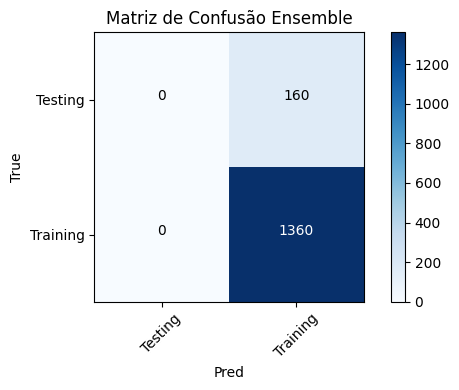

In [8]:
# ============================
# Resultados Finais
# ============================
acc = (y_pred == y_true.numpy()).mean()
f1m = f1_score(y_true.numpy(), y_pred, average='macro')
print(f"\n>> Ensemble Final | Acurácia: {acc:.4f} | F1 (macro): {f1m:.4f}\n")
print("Relatório de Classificação:\n", classification_report(y_true, y_pred, target_names=class_names))

def plot_cm(cm, classes, title="Matriz de Confusão Ensemble"):
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues); plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes)); plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i,j], 'd'), ha="center", color="white" if cm[i,j] > cm.max()/2 else "black")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names)